In [1]:
# Numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Dataset and splitting
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Decision-boundary visualization
from mlxtend.plotting import plot_decision_regions

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
X, y = make_circles(
    n_samples=1000,
    noise=0.10,
    factor=0.50,
    random_state=1
)

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

print("\nFirst 5 features:")
print(X[:5])

print("\nFirst 5 targets:")
print(y[:5])

Feature shape: (1000, 2)
Target shape : (1000,)

First 5 features:
[[ 0.6290374  -0.07157267]
 [-0.3460561  -0.52817133]
 [ 0.9246533  -0.71492522]
 [-0.10217077 -0.89283523]
 [-1.01719242  0.24737775]]

First 5 targets:
[1 1 0 0 0]


In [3]:
# Convert the dataset into a DataFrame for inspection
df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df["Target"] = y

print(df.head())
print("\nClass distribution:")
print(df["Target"].value_counts().sort_index())

   Feature_1  Feature_2  Target
0   0.629037  -0.071573       1
1  -0.346056  -0.528171       1
2   0.924653  -0.714925       0
3  -0.102171  -0.892835       0
4  -1.017192   0.247378       0

Class distribution:
Target
0    500
1    500
Name: count, dtype: int64


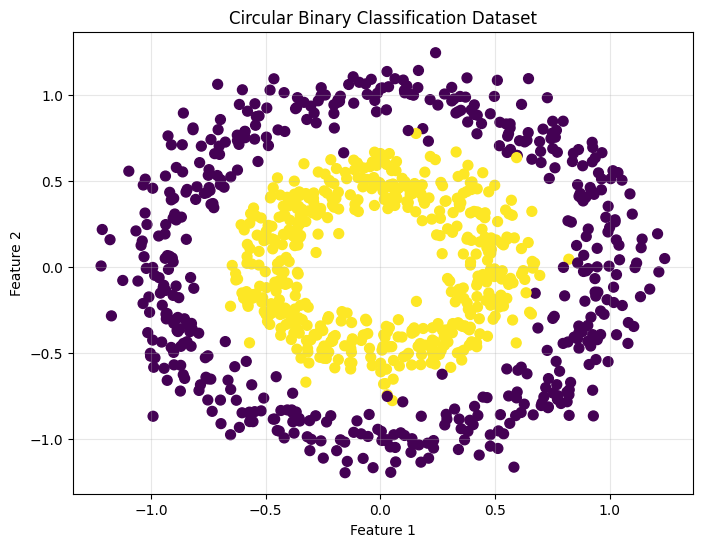

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)
plt.title("Circular Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# First: hold out 20% for final testing
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Second: split the remaining 80% into 80% training and 20% validation
# This gives 64% train, 16% validation, and 20% test overall.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_val
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples   :", len(X_test))

print("\nX_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

Training samples  : 640
Validation samples: 160
Testing samples   : 200

X_train shape: (640, 2)
X_val shape  : (160, 2)
X_test shape : (200, 2)

y_train shape: (640,)
y_val shape  : (160,)
y_test shape : (200,)


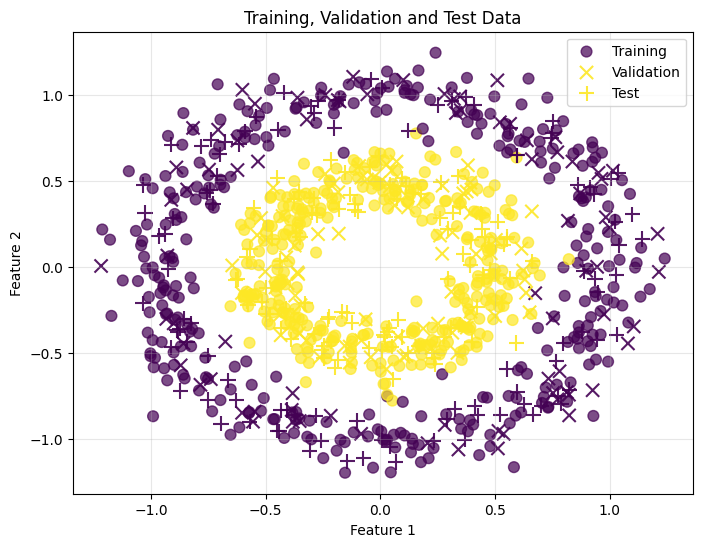

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=60, alpha=0.7, label="Training")
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, s=90, marker="x", alpha=0.9, label="Validation")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=120, marker="+", alpha=0.9, label="Test")

plt.title("Training, Validation and Test Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
def build_model():
    model = Sequential([
        Input(shape=(2,), name="Input_Layer"),
        Dense(256, activation="relu", name="Hidden_Layer"),
        Dense(1, activation="sigmoid", name="Output_Layer")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Maximum number of epochs for the comparison
MAX_EPOCHS = 1000

model = build_model()

history_no_es = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    verbose=0
)

print("Training completed.")
print("Epochs executed:", len(history_no_es.history["loss"]))

Training completed.
Epochs executed: 1000


In [9]:
history_no_es_df = pd.DataFrame(history_no_es.history)

print(history_no_es_df.head())

print("\nLast 10 epochs:")
print(history_no_es_df.tail(10))

   accuracy      loss  val_accuracy  val_loss
0  0.567187  0.685694       0.50000  0.673073
1  0.500000  0.661164       0.50000  0.650519
2  0.509375  0.641253       0.54375  0.628650
3  0.573438  0.619374       0.69375  0.603774
4  0.768750  0.593994       0.85000  0.576148

Last 10 epochs:
     accuracy      loss  val_accuracy  val_loss
990    0.9875  0.019326       0.99375  0.022598
991    0.9875  0.019323       0.99375  0.022640
992    0.9875  0.019326       0.99375  0.022643
993    0.9875  0.019305       0.99375  0.022647
994    0.9875  0.019331       0.99375  0.022662
995    0.9875  0.019306       0.99375  0.022615
996    0.9875  0.019307       0.99375  0.022624
997    0.9875  0.019305       0.99375  0.022647
998    0.9875  0.019332       0.99375  0.022664
999    0.9875  0.019301       0.99375  0.022666


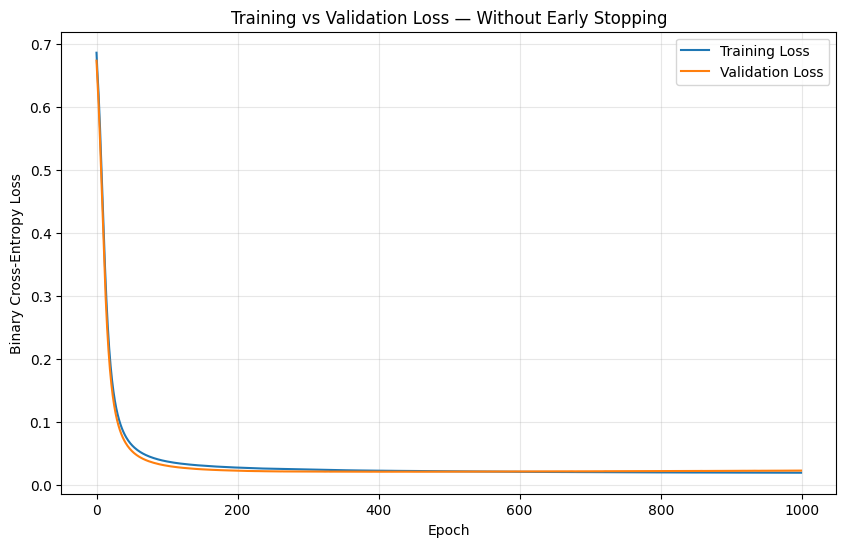

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(history_no_es.history["loss"], label="Training Loss")
plt.plot(history_no_es.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss — Without Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

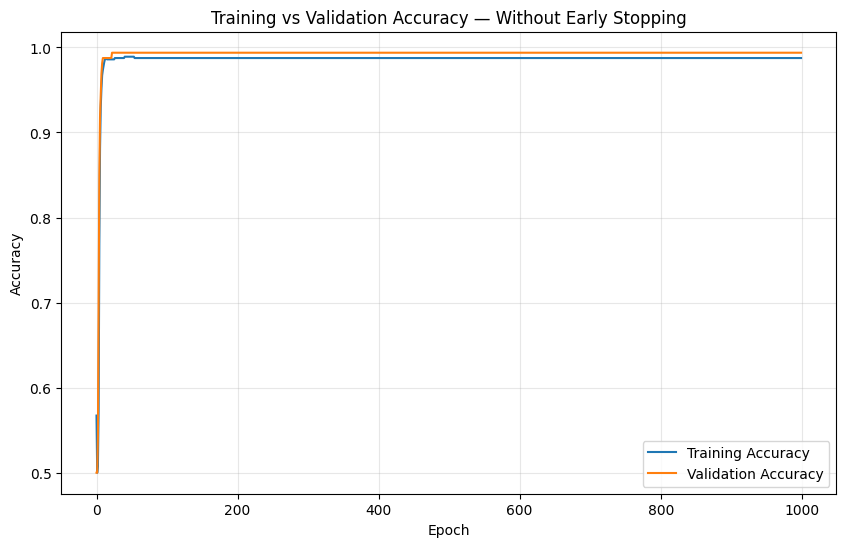

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(history_no_es.history["accuracy"], label="Training Accuracy")
plt.plot(history_no_es.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy — Without Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
val_loss_no_es = np.asarray(history_no_es.history["val_loss"])
best_epoch_no_es = int(np.argmin(val_loss_no_es) + 1)
best_val_loss_no_es = float(np.min(val_loss_no_es))

print("Best validation epoch:", best_epoch_no_es)
print("Best validation loss :", best_val_loss_no_es)

Best validation epoch: 417
Best validation loss : 0.020881468430161476


In [13]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-5,
    patience=20,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

print("Early stopping callback created.")
print(early_stopping)

Early stopping callback created.


In [14]:
# Fresh model = fair comparison
model_es = build_model()

history_es = model_es.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining finished.")
print("Epochs actually executed:", len(history_es.history["loss"]))

Epoch 1/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5219 - loss: 0.6734 - val_accuracy: 0.5000 - val_loss: 0.6599
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6491 - val_accuracy: 0.5063 - val_loss: 0.6370
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5312 - loss: 0.6273 - val_accuracy: 0.5875 - val_loss: 0.6133
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6609 - loss: 0.6033 - val_accuracy: 0.7312 - val_loss: 0.5869
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8297 - loss: 0.5760 - val_accuracy: 0.8875 - val_loss: 0.5574
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9109 - loss: 0.5461 - val_accuracy: 0.9375 - val_loss: 0.5263
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9438 - loss: 0.5151 - val_accuracy: 0.9625 - val_loss: 0.4946
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9594 - loss: 0.4835 - val_accuracy: 0

In [15]:
executed_epochs_es = len(history_es.history["loss"])
best_epoch_es = int(np.argmin(history_es.history["val_loss"]) + 1)
best_val_loss_es = float(np.min(history_es.history["val_loss"]))

print("Maximum requested epochs :", MAX_EPOCHS)
print("Actual epochs executed   :", executed_epochs_es)
print("Best validation epoch   :", best_epoch_es)
print("Best validation loss     :", best_val_loss_es)

Maximum requested epochs : 1000
Actual epochs executed   : 389
Best validation epoch   : 369
Best validation loss     : 0.020260563120245934


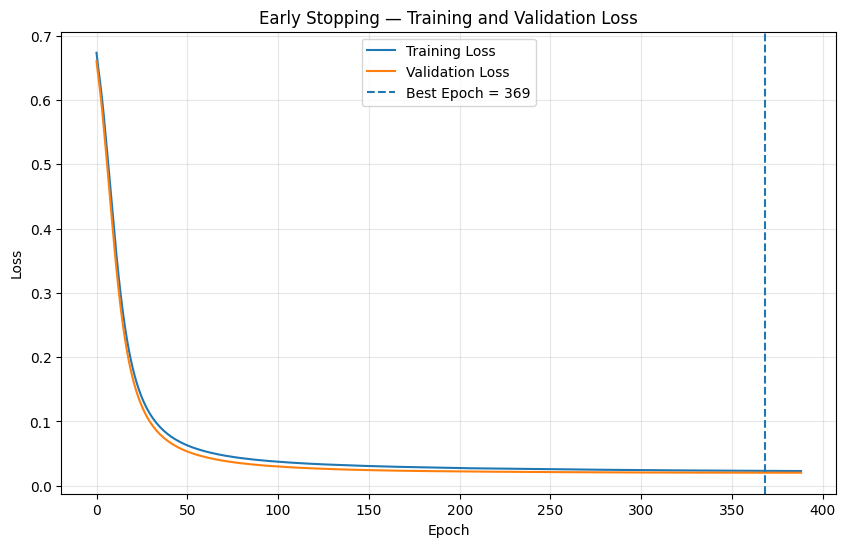

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(history_es.history["loss"], label="Training Loss")
plt.plot(history_es.history["val_loss"], label="Validation Loss")
plt.axvline(
    best_epoch_es - 1,
    linestyle="--",
    label=f"Best Epoch = {best_epoch_es}"
)
plt.title("Early Stopping — Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

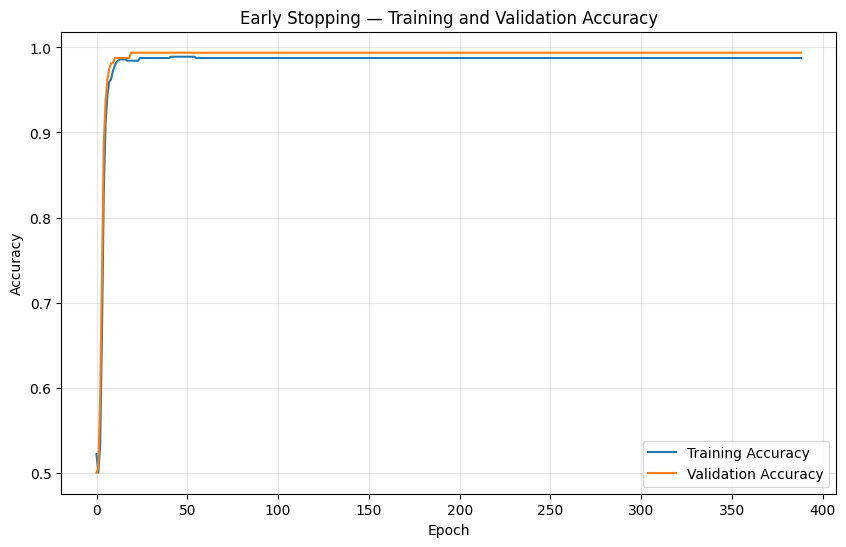

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(history_es.history["accuracy"], label="Training Accuracy")
plt.plot(history_es.history["val_accuracy"], label="Validation Accuracy")
plt.title("Early Stopping — Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Without Early Stopping",
        "With Early Stopping"
    ],
    "Maximum Epochs": [
        MAX_EPOCHS,
        MAX_EPOCHS
    ],
    "Actual Epochs": [
        len(history_no_es.history["loss"]),
        len(history_es.history["loss"])
    ],
    "Best Validation Loss": [
        float(np.min(history_no_es.history["val_loss"])),
        float(np.min(history_es.history["val_loss"]))
    ]
})

comparison

,Model,Maximum Epochs,Actual Epochs,Best Validation Loss
0,Without Early Stopping,1000,1000,0.020881
1,With Early Stopping,1000,389,0.020261


In [19]:
print("========== WITHOUT EARLY STOPPING ==========")
test_loss_1, test_accuracy_1 = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss_1:.4f}")
print(f"Test Accuracy : {test_accuracy_1:.4f}")

print("\n========== WITH EARLY STOPPING ==========")
test_loss_2, test_accuracy_2 = model_es.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss_2:.4f}")
print(f"Test Accuracy : {test_accuracy_2:.4f}")

========== WITHOUT EARLY STOPPING ==========
Test Loss     : 0.0125
Test Accuracy : 0.9950

========== WITH EARLY STOPPING ==========
Test Loss     : 0.0112
Test Accuracy : 0.9950


15000/15000 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step


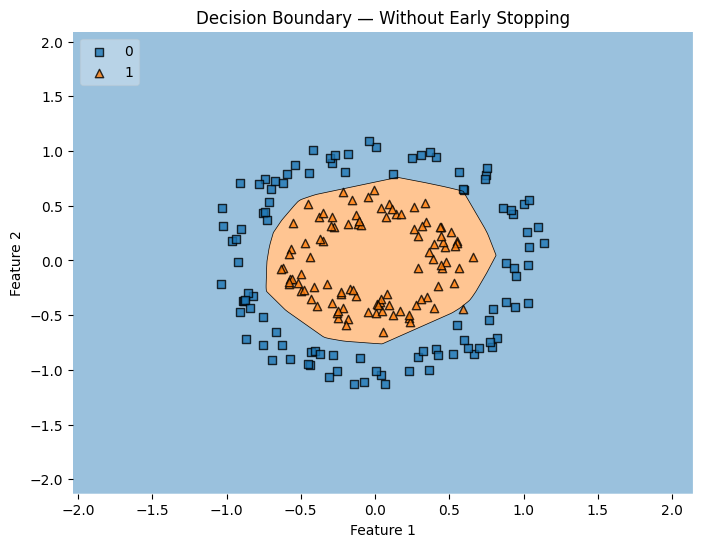

In [20]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X_test, y_test, clf=model, legend=2)
plt.title("Decision Boundary — Without Early Stopping")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

15000/15000 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step


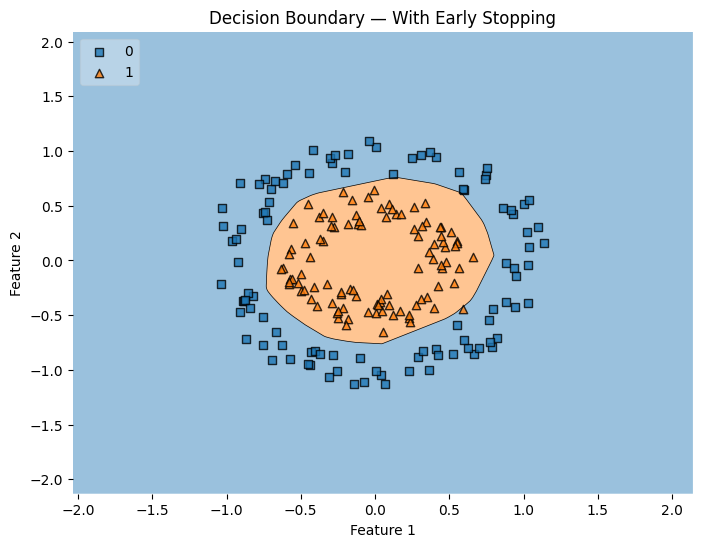

In [21]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X_test, y_test, clf=model_es, legend=2)
plt.title("Decision Boundary — With Early Stopping")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [22]:
# Probability and class predictions from the Early-Stopping model
y_probability = model_es.predict(X_test, verbose=0).ravel()
y_prediction = (y_probability >= 0.5).astype(int)

results = pd.DataFrame({
    "Actual": y_test,
    "Probability": y_probability,
    "Predicted": y_prediction
})

print(results.head(10))

print("\nTest accuracy from predictions:",
      accuracy_score(y_test, y_prediction))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_prediction))

print("\nClassification report:")
print(classification_report(y_test, y_prediction, digits=4))

   Actual   Probability  Predicted
0       1  9.999797e-01          1
1       0  4.869633e-09          0
2       0  4.215994e-04          0
3       0  8.093252e-05          0
4       1  9.919454e-01          1
5       1  9.999765e-01          1
6       1  9.959211e-01          1
7       1  9.999268e-01          1
8       0  9.922140e-07          0
9       0  2.374919e-01          0

Test accuracy from predictions: 0.995

Confusion matrix:
[[100   0]
 [  1  99]]

Classification report:
              precision    recall  f1-score   support

           0     0.9901    1.0000    0.9950       100
           1     1.0000    0.9900    0.9950       100

    accuracy                         0.9950       200
   macro avg     0.9950    0.9950    0.9950       200
weighted avg     0.9950    0.9950    0.9950       200



In [23]:
final_train_loss = float(history_es.history["loss"][-1])
final_val_loss = float(history_es.history["val_loss"][-1])
final_train_accuracy = float(history_es.history["accuracy"][-1])
final_val_accuracy = float(history_es.history["val_accuracy"][-1])

summary = pd.DataFrame({
    "Metric": [
        "Final Training Loss",
        "Final Validation Loss",
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "Best Validation Epoch",
        "Epochs Executed"
    ],
    "Value": [
        final_train_loss,
        final_val_loss,
        final_train_accuracy,
        final_val_accuracy,
        best_epoch_es,
        executed_epochs_es
    ]
})

summary

,Metric,Value
0,Final Training Loss,0.022882
1,Final Validation Loss,0.020281
2,Final Training Accuracy,0.987500
3,Final Validation Accuracy,0.993750
4,Best Validation Epoch,369.000000
5,Epochs Executed,389.000000


In [24]:
patience_values = [5, 10, 20, 30]
patience_results = []

for patience_value in patience_values:
    tf.keras.backend.clear_session()

    temp_model = build_model()

    temp_callback = EarlyStopping(
        monitor="val_loss",
        min_delta=1e-5,
        patience=patience_value,
        mode="min",
        restore_best_weights=True,
        verbose=0
    )

    temp_history = temp_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        callbacks=[temp_callback],
        verbose=0
    )

    patience_results.append({
        "Patience": patience_value,
        "Epochs": len(temp_history.history["loss"]),
        "Best Validation Loss": float(np.min(temp_history.history["val_loss"])),
        "Best Validation Accuracy": float(np.max(temp_history.history["val_accuracy"]))
    })

patience_df = pd.DataFrame(patience_results)
patience_df

,Patience,Epochs,Best Validation Loss,Best Validation Accuracy
0,5,299,0.021129,0.99375
1,10,377,0.020153,0.99375
2,20,409,0.020773,0.99375
3,30,437,0.020220,0.99375


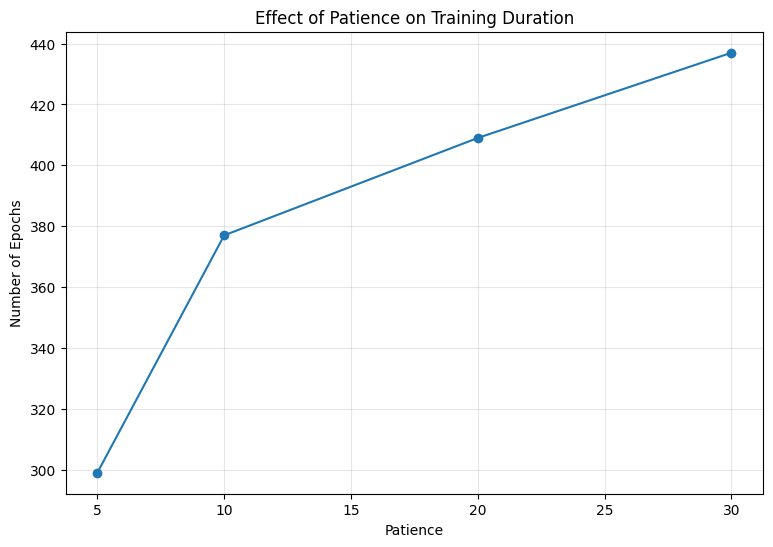

In [25]:
plt.figure(figsize=(9, 6))
plt.plot(patience_df["Patience"], patience_df["Epochs"], marker="o")
plt.title("Effect of Patience on Training Duration")
plt.xlabel("Patience")
plt.ylabel("Number of Epochs")
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
accuracy_callback = EarlyStopping(
    monitor="val_accuracy",
    min_delta=1e-4,
    patience=20,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

print("Accuracy-based Early Stopping callback:")
print(accuracy_callback)

Accuracy-based Early Stopping callback:
